In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

<Axes: xlabel='loc'>

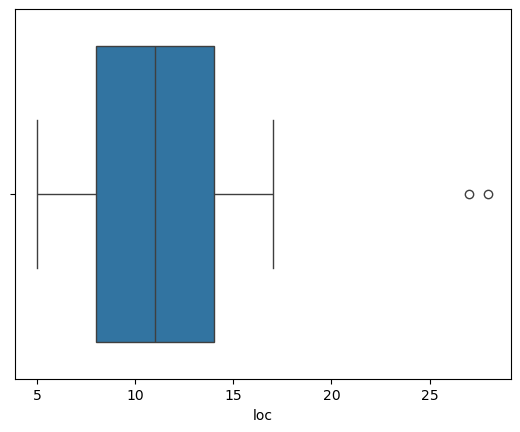

In [2]:
mopsa = '[Journault et al. 2019]'
mine = '[Miné 2017]'
ballabriga = '[Ballabriga et al. 2019]'
locs = np.array([
    [ "Own", "linear_constraint", 6 ],
    [ "Own", "sin_bounds", 27 ],
    [ "Own", "max_select", 7 ],
    [ "Own", "builtin_max", 7 ],
    [ "Own", "abs_if_join_on_stack", 10 ],
    [ "Own", "abs_if_join_on_local", 8 ],
    [ "Own", "abs_br_if_join_on_local", 9 ],
    [ "Own", "abs_select", 5 ],
    [ "Own", "plus_two_function_call", 8 ],
    [ "Own", "plus_five", 13 ],
    [ "Own", "reassignment", 8 ],
    [ "Own", "swap", 11 ],
    [ "Own", "loop_to_100", 10 ],
    [ "Own", "loop_condition_at_end", 9 ],
    [ "Own", "loop_over_int_array", 14 ],
    [ "Own", "mandelbrot_loop", 17 ],
    [ "Own", "tail_rec_loop_to_100", 11 ],
    [ "Own", "tail_rec_loop_to_n", 12 ],
    [ "Own", "fac_positive", 16 ],
    [ "Own", "fac_acc_positive", 16 ],
    [ "Own", "fib_positive", 16 ],
    [ "Own", "even_returns_boolean", 28 ],
    
    [ mopsa, "x_minus_x_eq_zero", 5 ],
    [ mopsa, "max_if", 10 ],
    [ mopsa, "loop_to_n", 12 ],
    [ mopsa, "2x_plus_y_minus_x_eq_x_plus_y", 13 ],
    [ mopsa, "input_of_recrusive_id_is_same_as_output", 5 ],
    [ mopsa, "peano_addition_loop", 14 ],
    
    [ mine, "5_1", 10 ],
    [ mine, "5_2", 13 ],
    [ mine, "5_11", 17 ],
    
    [ ballabriga, "12", 16 ],
    [ ballabriga, "13", 10 ]
])

locs = pd.DataFrame(locs, columns=['category', 'test', 'loc'])
locs['loc'] = locs['loc'].astype(pd.Int64Dtype())
locs['category'] = locs['category'].astype(pd.CategoricalDtype())

sns.boxplot(locs, x = 'loc')

In [11]:
df = pd.read_csv("relational-analysis-precision-test.csv")

polyhedra = df[df['domain'] == 'Polka']
polyhedra.insert(3, 'category', locs['category'])

octagon = df[df['domain'] == 'Octagon'].reset_index()
octagon.insert(3, 'category', locs['category'])

intervals =  df[(df['domain'] == 'Box') & (df['relational'] == True)].reset_index()
intervals.insert(3, 'category', locs['category'])

non_relational = df[(df['domain'] == 'Box') & (df['relational'] == False)].reset_index()
non_relational.insert(3, 'category', locs['category'])
non_relational['domain'] = 'Non Relational'

df = pd.concat([polyhedra, octagon, intervals, non_relational], ignore_index=True).drop(['index', 'relational', 'ssa'], axis=1)
df

,domain,category,test,precise,env_size,byte_size
0,Polka,Own,linear_constraint,True,6,78
1,Polka,Own,sin_bounds,True,3,45
2,Polka,Own,max_select,True,7,126
3,Polka,Own,builtin_max,False,7,245
4,Polka,Own,abs_if_join_on_stack,True,5,70
...,...,...,...,...,...,...
127,Non Relational,[Miné 2017],static_inference_numeric_invariants_example_5_1,False,0,0
128,Non Relational,[Miné 2017],static_inference_numeric_invariants_example_5_2,False,0,0
129,Non Relational,[Miné 2017],static_inference_numeric_invariants_example_5_11,False,0,0
130,Non Relational,[Ballabriga et al. 2019],static_analysis_binary_code_example_12,False,0,0


In [31]:
precision = df.drop(['test','env_size','byte_size'], axis=1)
precision = precision.assign(tests = 1).groupby(by=['domain', 'category']).sum()
precision = precision.assign(precision = precision['precise'] / precision['tests'] * 100)
display(precision)

precision = precision.reset_index().drop(['category'],axis=1).groupby(by=['domain']).sum()
precision = precision.assign(precision = precision['precise'] / precision['tests'] * 100)
display(precision)

precision = precision.reset_index()

display(float(precision[precision['domain'] == 'Polka']['precision']) - float(precision[precision['domain'] == 'Non Relational']['precision']))
display(float(precision[precision['domain'] == 'Octagon']['precision']) - float(precision[precision['domain'] == 'Non Relational']['precision']))

# precise = df[df['precise'] == True]
# tests = pd.unique(df['test'])

# precision = precise.drop(['test','env_size','byte_size', 'category'], axis=1).groupby(by=['domain']).sum()
# display(precision)
# precision['precision'] = precision / len(tests) * 100
# precision.insert(1, 'tests', len(tests))
# display(precision)

/tmp/ipykernel_17968/3523623364.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  precision = precision.assign(tests = 1).groupby(by=['domain', 'category']).sum()


precise  tests  precision
domain         category                                           
Box            Own                             8     22  36.363636
               [Ballabriga et al. 2019]        0      2   0.000000
               [Journault et al. 2019]         0      6   0.000000
               [Miné 2017]                     0      3   0.000000
Non Relational Own                             5     22  22.727273
               [Ballabriga et al. 2019]        0      2   0.000000
               [Journault et al. 2019]         0      6   0.000000
               [Miné 2017]                     0      3   0.000000
Octagon        Own                            16     22  72.727273
               [Ballabriga et al. 2019]        0      2   0.000000
               [Journault et al. 2019]         2      6  33.333333
               [Miné 2017]                     0      3   0.000000
Polka          Own                            16     22  72.727273
               [Ballabriga et al. 2019]        0      2   0.000000
               [Journault et al. 2019]         3      6  50.000000
               [Miné 2017]                     1      3  33.333333

,precise,tests,precision
domain,,,
Box,8,33,24.242424
Non Relational,5,33,15.151515
Octagon,18,33,54.545455
Polka,20,33,60.606061


/tmp/ipykernel_17968/3523623364.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  display(float(precision[precision['domain'] == 'Polka']['precision']) - float(precision[precision['domain'] == 'Non Relational']['precision']))


45.45454545454545

/tmp/ipykernel_17968/3523623364.py:13: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  display(float(precision[precision['domain'] == 'Octagon']['precision']) - float(precision[precision['domain'] == 'Non Relational']['precision']))


39.39393939393939

In [21]:
df[['relational','ssa', 'domain','env_size','byte_size']].groupby(by=['relational','ssa', 'domain']).describe()

env_size                                            \
                            count      mean       std  min  25%  50%    75%   
relational ssa   domain                                                       
False      False Box         30.0  0.000000  0.000000  0.0  0.0  0.0   0.00   
True       False Box         30.0  5.433333  2.223438  2.0  4.0  5.5   6.75   
                 Octagon     30.0  5.500000  2.270500  2.0  4.0  5.5   7.00   
                 Polka       30.0  5.500000  2.270500  2.0  4.0  5.5   7.00   
           True  Box         30.0  9.133333  4.811863  3.0  6.0  7.0  12.75   
                 Octagon     30.0  9.166667  4.821527  3.0  6.0  7.0  12.75   
                 Polka       30.0  9.200000  4.964703  3.0  6.0  7.0  12.75   

                               byte_size                                       \
                           max     count        mean         std   min    25%   
relational ssa   domain                                                         
False      False Box       0.0      30.0    0.000000    0.000000   0.0   0.00   
True       False Box      10.0      30.0   10.866667    4.446877   4.0   8.00   
                 Octagon  10.0      30.0   41.000000   50.992900   1.0   1.00   
                 Polka    10.0      30.0  127.100000  108.480524  18.0  62.50   
           True  Box      20.0      30.0   18.266667    9.623725   6.0  12.00   
                 Octagon  20.0      30.0  125.833333  162.130872   1.0   1.00   
                 Polka    21.0      30.0  457.133333  953.478088  32.0  88.25   

                                                 
                            50%     75%     max  
relational ssa   domain                          
False      False Box        0.0    0.00     0.0  
True       False Box       11.0   13.50    20.0  
                 Octagon   12.0   78.00   180.0  
                 Polka    105.0  125.75   480.0  
           True  Box       14.0   25.50    40.0  
                 Octagon   30.5  253.00   480.0  
                 Polka    177.0  303.00  4121.0

11.0

<Axes: xlabel='loc'>

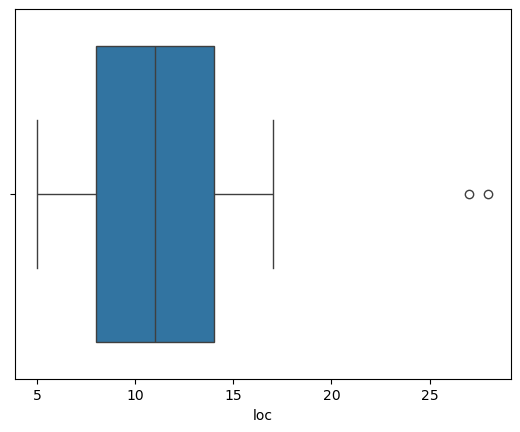